In [13]:
# 1. Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from transformers import BertModel, BertTokenizer, GPT2Tokenizer, GPT2Model
from sentence_transformers import SentenceTransformer

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /home/stranger/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/stranger/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/stranger/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [14]:
# 2. Загрузка и подготовка данных (первые 1000 строк)
data = pd.read_csv('email_text.csv', nrows=1000)

# Проверка и удаление null-значений
data = data.dropna()

# Просмотр первых строк данных
print(data.head())
print(data.shape)

   label                                               text
0      0  the mailing list i queried about a few weeks a...
1      1  luxury watches buy your own rolex for only esc...
2      1  academic qualifications available from prestig...
3      0  greetings all this is to verify your subscript...
4      1  try chauncey may conferred the luscious not co...
(1000, 2)


In [15]:
# 3. Предобработка текста
def text_cleaner(text):
    # Преобразование текста в нижний регистр
    text = text.lower()

    # Удаление лишних пробелов
    text = re.sub(r'\s+', ' ', text)

    # Преобразование сокращений
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"can't", "cannot", text)
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'d", " would", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'s", " is", text)
    text = re.sub(r"'m", " am", text)

    # Удаление знаков препинания
    text = re.sub(r'[^\w\s]', '', text)

    # Удаление стоп-слов
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text)
    filtered_text = [word for word in tokens if word.lower() not in stop_words]

    # Лемматизация слов
    lemmatizer = WordNetLemmatizer()
    lemmatized_text = [lemmatizer.lemmatize(word) for word in filtered_text]

    # Объединение лемматизированных слов обратно в текст
    cleaned_text = ' '.join(lemmatized_text)

    return cleaned_text

# Применение функции предобработки к текстам
data['cleaned_text'] = data['text'].map(lambda x: text_cleaner(x))

# Просмотр результатов предобработки
print(data[['text', 'cleaned_text']].head())

                                                text  \
0  the mailing list i queried about a few weeks a...   
1  luxury watches buy your own rolex for only esc...   
2  academic qualifications available from prestig...   
3  greetings all this is to verify your subscript...   
4  try chauncey may conferred the luscious not co...   

                                        cleaned_text  
0  mailing list queried week ago running also set...  
1  luxury watch buy rolex escapenumber rolex cart...  
2  academic qualification available prestigious n...  
3  greeting verify subscription planescapenumber ...  
4  try chauncey may conferred luscious continued ...  


In [16]:
# 4. Получение эмбеддингов с помощью BERT
# Загрузка предобученной модели BERT
bert_model_name = 'bert-base-uncased'
bert_tokenizer = BertTokenizer.from_pretrained(bert_model_name)
bert_model = SentenceTransformer(bert_model_name)

# Получение эмбеддингов
bert_embeddings = bert_model.encode(data['cleaned_text'].tolist())
print(f"BERT Embeddings shape: {bert_embeddings.shape}")

No sentence-transformers model found with name bert-base-uncased. Creating a new one with mean pooling.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1940.15it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT Embeddings shape: (1000, 768)


In [17]:
# 5. Получение эмбеддингов с помощью GPT-2
# Загрузка предобученной модели GPT-2
gpt2_model_name = 'gpt2'
gpt2_tokenizer = GPT2Tokenizer.from_pretrained(gpt2_model_name)
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token
gpt2_model = GPT2Model.from_pretrained(gpt2_model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpt2_model.to(device)

# Tokenize и pad sequences
encoded_texts = gpt2_tokenizer(
    data['cleaned_text'].tolist(),
    return_tensors='pt',
    padding=True,
    truncation=True
)
encoded_texts = {key: value.to(device) for key, value in encoded_texts.items()}

batch_size = 4
all_gpt2_embeddings = []

# Разделим данные на батчи и передадим их в модель
for i in range(0, len(encoded_texts['input_ids']), batch_size):
    batch_input_ids = encoded_texts['input_ids'][i:i+batch_size].to(device)
    batch_attention_mask = encoded_texts['attention_mask'][i:i+batch_size].to(device)

    with torch.no_grad():
        batch_outputs = gpt2_model(batch_input_ids, attention_mask=batch_attention_mask)

    word_embeddings = batch_outputs.last_hidden_state
    masked_word_embeddings = word_embeddings * batch_attention_mask.unsqueeze(-1).float()
    sentence_embeddings = masked_word_embeddings.sum(dim=1)
    sentence_embeddings /= batch_attention_mask.sum(dim=1, keepdim=True).float()

    all_gpt2_embeddings.append(sentence_embeddings)

all_gpt2_embeddings = torch.cat(all_gpt2_embeddings, dim=0)
gpt2_embeddings = all_gpt2_embeddings.cpu().numpy()

print(f"GPT-2 Embeddings shape: {gpt2_embeddings.shape}")

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1459.77it/s, Materializing param=wte.weight]             
GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT-2 Embeddings shape: (1000, 768)


In [18]:
# 6. Разделение данных на обучающую и тестовую выборки

# Проверка уникальных значений меток
print("Уникальные значения меток после преобразования:", data['label'].unique())
print("Количество пропущенных значений:", data['label'].isnull().sum())


# Разделение данных для BERT
X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(
    bert_embeddings, data['label'].values, test_size=0.2, random_state=42
)

# Разделение данных для GPT-2
X_train_gpt2, X_test_gpt2, y_train_gpt2, y_test_gpt2 = train_test_split(
    gpt2_embeddings, data['label'].values, test_size=0.2, random_state=42
)

Уникальные значения меток после преобразования: [0 1]
Количество пропущенных значений: 0


In [19]:
# 7. Преобразование данных в тензоры PyTorch и создание DataLoader
# Для BERT
X_train_bert_tensor = torch.tensor(X_train_bert, dtype=torch.float32)
X_test_bert_tensor = torch.tensor(X_test_bert, dtype=torch.float32)
y_train_bert_tensor = torch.tensor(y_train_bert, dtype=torch.float32).unsqueeze(1)
y_test_bert_tensor = torch.tensor(y_test_bert, dtype=torch.float32).unsqueeze(1)

train_dataset_bert = TensorDataset(X_train_bert_tensor, y_train_bert_tensor)
test_dataset_bert = TensorDataset(X_test_bert_tensor, y_test_bert_tensor)

train_loader_bert = DataLoader(train_dataset_bert, batch_size=32, shuffle=True)
test_loader_bert = DataLoader(test_dataset_bert, batch_size=32)

# Для GPT-2
X_train_gpt2_tensor = torch.tensor(X_train_gpt2, dtype=torch.float32)
X_test_gpt2_tensor = torch.tensor(X_test_gpt2, dtype=torch.float32)
y_train_gpt2_tensor = torch.tensor(y_train_gpt2, dtype=torch.float32).unsqueeze(1)
y_test_gpt2_tensor = torch.tensor(y_test_gpt2, dtype=torch.float32).unsqueeze(1)

train_dataset_gpt2 = TensorDataset(X_train_gpt2_tensor, y_train_gpt2_tensor)
test_dataset_gpt2 = TensorDataset(X_test_gpt2_tensor, y_test_gpt2_tensor)

train_loader_gpt2 = DataLoader(train_dataset_gpt2, batch_size=32, shuffle=True)
test_loader_gpt2 = DataLoader(test_dataset_gpt2, batch_size=32)

In [20]:
# 8. Определение архитектуры нейронной сети для бинарной классификации
class SpamClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout_prob=0.5):
        super(SpamClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.sigmoid(out)
        return out

Epoch 1, Train Loss: 0.5587, Train Accuracy: 0.6975, Test Loss: 0.3814, Test Accuracy: 0.8950
Epoch 2, Train Loss: 0.3610, Train Accuracy: 0.8675, Test Loss: 0.2407, Test Accuracy: 0.9100
Epoch 3, Train Loss: 0.2625, Train Accuracy: 0.9050, Test Loss: 0.1989, Test Accuracy: 0.9200
Epoch 4, Train Loss: 0.1912, Train Accuracy: 0.9437, Test Loss: 0.1727, Test Accuracy: 0.9700
Epoch 5, Train Loss: 0.1611, Train Accuracy: 0.9487, Test Loss: 0.1635, Test Accuracy: 0.9600
Epoch 6, Train Loss: 0.1350, Train Accuracy: 0.9525, Test Loss: 0.1470, Test Accuracy: 0.9750
Epoch 7, Train Loss: 0.1138, Train Accuracy: 0.9688, Test Loss: 0.1225, Test Accuracy: 0.9750
Epoch 8, Train Loss: 0.1064, Train Accuracy: 0.9663, Test Loss: 0.1506, Test Accuracy: 0.9700
Epoch 9, Train Loss: 0.0796, Train Accuracy: 0.9812, Test Loss: 0.1155, Test Accuracy: 0.9750
Epoch 10, Train Loss: 0.0860, Train Accuracy: 0.9663, Test Loss: 0.1392, Test Accuracy: 0.9700


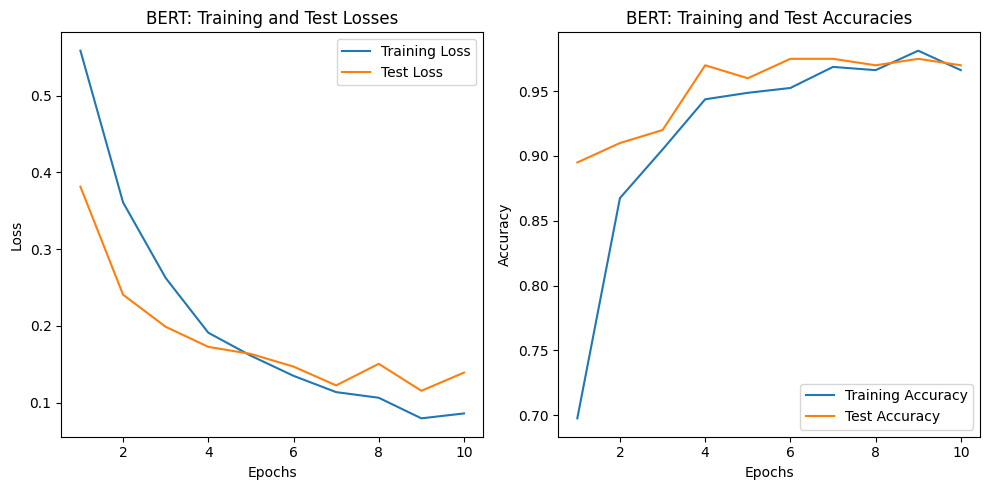

BERT Accuracy: 0.9700
BERT F1-score: 0.9492


In [21]:
# 9. Обучение и оценка модели BERT
# Параметры модели
input_size_bert = bert_embeddings.shape[1]
hidden_size = 256
output_size = 1

# Создание модели
model_bert = SpamClassifier(input_size_bert, hidden_size, output_size)

# Определение функции потерь и оптимизатора
criterion = nn.BCELoss()
optimizer_bert = optim.Adam(model_bert.parameters(), lr=0.001)

# Пустые списки для хранения значений потерь и точности
train_losses_bert = []
train_accuracies_bert = []
test_losses_bert = []
test_accuracies_bert = []

# Обучение модели
num_epochs = 10
for epoch in range(num_epochs):
    model_bert.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader_bert:
        optimizer_bert.zero_grad()
        outputs = model_bert(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_bert.step()
        running_loss += loss.item()

        # Вычисление точности на обучающей выборке
        predictions = (outputs > 0.5).float()
        correct_train += (predictions == labels).sum().item()
        total_train += labels.size(0)

    train_losses_bert.append(running_loss / len(train_loader_bert))
    train_accuracies_bert.append(correct_train / total_train)

    # Оценка модели на тестовой выборке
    model_bert.eval()
    test_loss = 0.0
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for inputs, labels in test_loader_bert:
            outputs = model_bert(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            predictions = (outputs > 0.5).float()
            correct_test += (predictions == labels).sum().item()
            total_test += labels.size(0)

    test_losses_bert.append(test_loss / len(test_loader_bert))
    test_accuracies_bert.append(correct_test / total_test)

    print(f"Epoch {epoch+1}, Train Loss: {train_losses_bert[-1]:.4f}, Train Accuracy: {train_accuracies_bert[-1]:.4f}, Test Loss: {test_losses_bert[-1]:.4f}, Test Accuracy: {test_accuracies_bert[-1]:.4f}")

# Построение графиков
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses_bert, label='Training Loss')
plt.plot(range(1, num_epochs+1), test_losses_bert, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('BERT: Training and Test Losses')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies_bert, label='Training Accuracy')
plt.plot(range(1, num_epochs+1), test_accuracies_bert, label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('BERT: Training and Test Accuracies')
plt.legend()

plt.tight_layout()
plt.show()

# Расчет метрик на тестовой выборке
model_bert.eval()
with torch.no_grad():
    test_outputs = model_bert(X_test_bert_tensor)
    test_predictions = (test_outputs > 0.5).float().numpy()

bert_accuracy = accuracy_score(y_test_bert, test_predictions)
bert_f1 = f1_score(y_test_bert, test_predictions)

print(f"BERT Accuracy: {bert_accuracy:.4f}")
print(f"BERT F1-score: {bert_f1:.4f}")

Epoch 1, Train Loss: 0.8509, Train Accuracy: 0.6038, Test Loss: 0.3519, Test Accuracy: 0.9000
Epoch 2, Train Loss: 0.4722, Train Accuracy: 0.7825, Test Loss: 0.2438, Test Accuracy: 0.9000
Epoch 3, Train Loss: 0.3427, Train Accuracy: 0.8375, Test Loss: 0.1764, Test Accuracy: 0.9400
Epoch 4, Train Loss: 0.2645, Train Accuracy: 0.9000, Test Loss: 0.1434, Test Accuracy: 0.9800
Epoch 5, Train Loss: 0.2427, Train Accuracy: 0.9062, Test Loss: 0.1098, Test Accuracy: 0.9800
Epoch 6, Train Loss: 0.2196, Train Accuracy: 0.9150, Test Loss: 0.1425, Test Accuracy: 0.9600
Epoch 7, Train Loss: 0.1837, Train Accuracy: 0.9387, Test Loss: 0.1124, Test Accuracy: 0.9500
Epoch 8, Train Loss: 0.1668, Train Accuracy: 0.9475, Test Loss: 0.0786, Test Accuracy: 0.9800
Epoch 9, Train Loss: 0.1358, Train Accuracy: 0.9563, Test Loss: 0.0732, Test Accuracy: 0.9800
Epoch 10, Train Loss: 0.1282, Train Accuracy: 0.9663, Test Loss: 0.0679, Test Accuracy: 0.9800


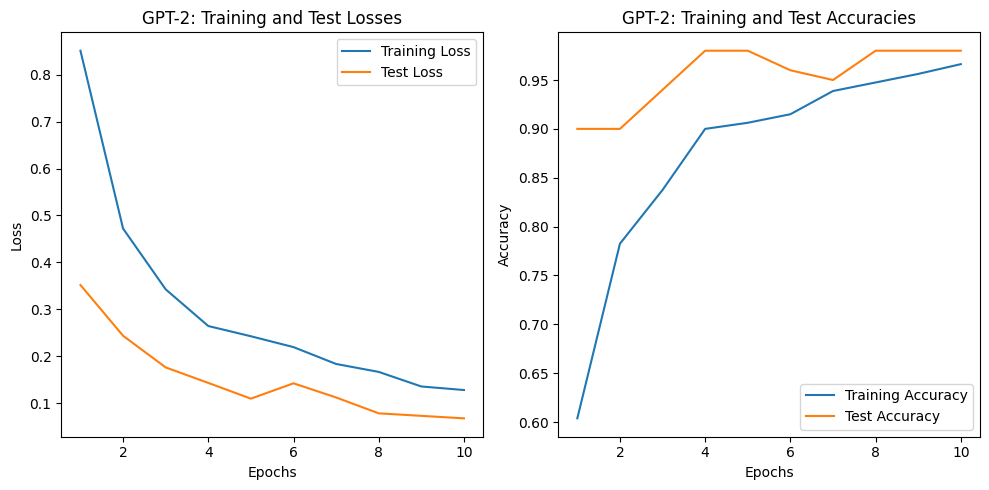

GPT-2 Accuracy: 0.9800
GPT-2 F1-score: 0.9672


In [22]:
# 10. Обучение и оценка модели GPT-2
# Параметры модели
input_size_gpt2 = gpt2_embeddings.shape[1]
hidden_size = 256
output_size = 1

# Создание модели
model_gpt2 = SpamClassifier(input_size_gpt2, hidden_size, output_size)

# Определение функции потерь и оптимизатора
criterion = nn.BCELoss()
optimizer_gpt2 = optim.Adam(model_gpt2.parameters(), lr=0.001)

# Пустые списки для хранения значений потерь и точности
train_losses_gpt2 = []
train_accuracies_gpt2 = []
test_losses_gpt2 = []
test_accuracies_gpt2 = []

# Обучение модели
num_epochs = 10
for epoch in range(num_epochs):
    model_gpt2.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader_gpt2:
        optimizer_gpt2.zero_grad()
        outputs = model_gpt2(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_gpt2.step()
        running_loss += loss.item()

        # Вычисление точности на обучающей выборке
        predictions = (outputs > 0.5).float()
        correct_train += (predictions == labels).sum().item()
        total_train += labels.size(0)

    train_losses_gpt2.append(running_loss / len(train_loader_gpt2))
    train_accuracies_gpt2.append(correct_train / total_train)

    # Оценка модели на тестовой выборке
    model_gpt2.eval()
    test_loss = 0.0
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for inputs, labels in test_loader_gpt2:
            outputs = model_gpt2(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            predictions = (outputs > 0.5).float()
            correct_test += (predictions == labels).sum().item()
            total_test += labels.size(0)

    test_losses_gpt2.append(test_loss / len(test_loader_gpt2))
    test_accuracies_gpt2.append(correct_test / total_test)

    print(f"Epoch {epoch+1}, Train Loss: {train_losses_gpt2[-1]:.4f}, Train Accuracy: {train_accuracies_gpt2[-1]:.4f}, Test Loss: {test_losses_gpt2[-1]:.4f}, Test Accuracy: {test_accuracies_gpt2[-1]:.4f}")

# Построение графиков
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses_gpt2, label='Training Loss')
plt.plot(range(1, num_epochs+1), test_losses_gpt2, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('GPT-2: Training and Test Losses')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies_gpt2, label='Training Accuracy')
plt.plot(range(1, num_epochs+1), test_accuracies_gpt2, label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('GPT-2: Training and Test Accuracies')
plt.legend()

plt.tight_layout()
plt.show()

# Расчет метрик на тестовой выборке
model_gpt2.eval()
with torch.no_grad():
    test_outputs = model_gpt2(X_test_gpt2_tensor)
    test_predictions = (test_outputs > 0.5).float().numpy()

gpt2_accuracy = accuracy_score(y_test_gpt2, test_predictions)
gpt2_f1 = f1_score(y_test_gpt2, test_predictions)

print(f"GPT-2 Accuracy: {gpt2_accuracy:.4f}")
print(f"GPT-2 F1-score: {gpt2_f1:.4f}")

In [23]:
# 11. Сравнение методов получения эмбеддингов
# Сравнение метрик
print("Сравнение методов получения эмбеддингов:")
print(f"BERT - Accuracy: {bert_accuracy:.4f}, F1-score: {bert_f1:.4f}")
print(f"GPT-2 - Accuracy: {gpt2_accuracy:.4f}, F1-score: {gpt2_f1:.4f}")

if bert_f1 > gpt2_f1:
    print("\nBERT показал лучший результат по F1-score")
    print("Причина: BERT обучен на задачах маскированного языкового моделирования и лучше улавливает контекстные зависимости")
else:
    print("\nGPT-2 показал лучший результат по F1-score")
    print("Причина: GPT-2 имеет архитектуру генеративной модели и может лучше генерировать связанные последовательности текста")

Сравнение методов получения эмбеддингов:
BERT - Accuracy: 0.9700, F1-score: 0.9492
GPT-2 - Accuracy: 0.9800, F1-score: 0.9672

GPT-2 показал лучший результат по F1-score
Причина: GPT-2 имеет архитектуру генеративной модели и может лучше генерировать связанные последовательности текста
